# Modelado y evaluación final

Con el dataset ya consolidado y optimizado durante las etapas anteriores, comienza la fase de modelado final orientada a entrenar, ajustar y comparar distintos algoritmos de Machine Learning para la predicción de lluvia.

Inicialmente, se carga la versión definitiva del dataset procesado y se separan nuevamente las variables predictoras (`X`) de la variable objetivo (`y`). Luego de todo el proceso de limpieza y selección de características, el conjunto final queda conformado por variables meteorológicas relacionadas con:

- temperatura
- presión atmosférica
- humedad relativa
- viento
- estacionalidad temporal

Posteriormente, se realiza la división entre conjuntos de entrenamiento y prueba utilizando una proporción 80/20. La utilización de `stratify=y` garantiza que ambas particiones mantengan una distribución equilibrada de clases, permitiendo una evaluación más representativa del rendimiento de los modelos.

A continuación, se importan las herramientas necesarias para el proceso de optimización y validación:

- `Pipeline` para encapsular el flujo completo de procesamiento y entrenamiento
- `SimpleImputer` para el tratamiento de valores faltantes
- `StandardScaler` para normalización de variables
- `RandomizedSearchCV` para búsqueda eficiente de hiperparámetros
- `StratifiedKFold` para validación cruzada estratificada

La validación cruzada se configura utilizando 5 particiones aleatorias y estratificadas, permitiendo obtener métricas más robustas y reducir el riesgo de sobreajuste durante la selección del modelo final.

Esta etapa representa el núcleo del proceso de Machine Learning, donde se evaluará el comportamiento de distintos algoritmos y configuraciones con el objetivo de encontrar la combinación con mejor capacidad predictiva y generalización.

In [4]:
import pandas as pd
import numpy as np

# Carga
df = pd.read_csv("../../data/processed/weather_processed.csv")

X = df.drop(columns=["Rain"])
y = df["Rain"]

print(X.columns.tolist())

['TMAX', 'TMIN', 'ADPT', 'ASLP', 'ASTP', 'AWBT', 'AWND', 'RHAV', 'RHMN', 'RHMX', 'WDF2', 'WDF5', 'WSF2', 'WSF5', 'month', 'dayofweek', 'month_sin', 'month_cos']


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Configuración y optimización de la regresión logística

Como punto de partida para el proceso de modelado, se define un pipeline basado en regresión logística. Este algoritmo funciona como una línea base sólida debido a su simplicidad, interpretabilidad y bajo costo computacional, permitiendo comparar posteriormente modelos más complejos.

El pipeline incorpora tres etapas principales:

- imputación de valores faltantes mediante la media
- normalización de variables utilizando `StandardScaler`
- entrenamiento del modelo `LogisticRegression`

La normalización resulta especialmente importante en modelos lineales, ya que evita que variables con escalas más grandes dominen el proceso de optimización y afecten el cálculo de los coeficientes.

Posteriormente, se construye un espacio de búsqueda de hiperparámetros (`param_log`) para explorar distintas configuraciones del modelo. Entre los parámetros evaluados se incluyen:

- `C`: controla la intensidad de regularización
- `penalty`: tipo de penalización aplicada
- `solver`: algoritmo utilizado para resolver la optimización

Donde:

- `Loss` representa el error de clasificación
- `λ` controla la fuerza de regularización
- `||w||²` corresponde a la magnitud de los coeficientes del modelo

Para automatizar la búsqueda de la mejor combinación de hiperparámetros, se implementa `RandomizedSearchCV`. Este enfoque permite evaluar múltiples configuraciones de manera eficiente utilizando validación cruzada estratificada.

La optimización se realiza utilizando:

- 10 combinaciones aleatorias de hiperparámetros
- validación cruzada de 5 particiones (`cv`)
- métrica de evaluación `ROC-AUC`
- ejecución paralela mediante `n_jobs=-1`

La elección de `ROC-AUC` como métrica principal resulta especialmente útil en problemas de clasificación binaria, ya que permite evaluar la capacidad del modelo para distinguir correctamente entre días con lluvia y sin lluvia independientemente del umbral de clasificación seleccionado.

In [7]:
from sklearn.linear_model import LogisticRegression

pipeline_log = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [8]:
param_log = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],  # seguro
    "model__solver": ["lbfgs", "liblinear", "sag"]
}

In [9]:
search_log = RandomizedSearchCV(
    pipeline_log,
    param_distributions=param_log,
    n_iter=10,
    scoring="roc_auc",
    cv= cv,
    random_state=42,
    n_jobs=-1
)

## Configuración y optimización del modelo SVM

Con el objetivo de explorar modelos capaces de capturar relaciones no lineales complejas, se implementa un pipeline basado en `Support Vector Machine` (`SVC`).

El pipeline mantiene la misma estructura general utilizada en modelos anteriores:

- imputación de valores faltantes mediante la media
- normalización de variables con `StandardScaler`
- entrenamiento del clasificador SVM

La etapa de escalado resulta fundamental en este algoritmo, ya que SVM es altamente sensible a las magnitudes de las variables. Sin normalización, características con escalas mayores podrían dominar el cálculo de distancias y afectar negativamente la separación entre clases.

Además, se habilita el parámetro `probability=True`, permitiendo obtener probabilidades de clasificación necesarias para evaluar el modelo mediante métricas como `ROC-AUC`.

Posteriormente, se define un espacio de búsqueda de hiperparámetros (`param_svm`) orientado a explorar distintas configuraciones del modelo:

- `C`: controla el nivel de regularización
- `gamma`: define la influencia de cada observación sobre la frontera de decisión
- `kernel`: tipo de transformación utilizada para separar las clases

La búsqueda incluye tanto un kernel lineal (`linear`) como un kernel radial (`rbf`). El kernel radial permite modelar relaciones no lineales más complejas proyectando los datos a espacios de mayor dimensionalidad.

Para automatizar la optimización, se utiliza `RandomizedSearchCV`, evaluando distintas combinaciones de hiperparámetros mediante validación cruzada estratificada.

La configuración utilizada incluye:

- 10 combinaciones aleatorias
- validación cruzada de 5 particiones
- optimización basada en `ROC-AUC`
- procesamiento paralelo mediante `n_jobs=-1`

Debido a su capacidad para manejar fronteras de decisión complejas y espacios de alta dimensionalidad, SVM representa uno de los candidatos más prometedores para el problema de predicción de lluvia planteado en este proyecto.

In [10]:
from sklearn.svm import SVC

pipeline_svm = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True))
])

In [11]:
param_svm = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.1, 0.01, 0.001],
    "model__kernel": ["linear", "rbf"]
}

In [12]:
search_svm = RandomizedSearchCV(
    pipeline_svm,
    param_distributions=param_svm,
    n_iter=10,
    scoring="roc_auc",
    cv= cv,
    random_state=42,
    n_jobs=-1
)

## Configuración y optimización del modelo XGBoost

Como último modelo del proceso comparativo, se implementa `XGBoostClassifier`, uno de los algoritmos de *gradient boosting* más utilizados en problemas tabulares debido a su alto rendimiento, flexibilidad y capacidad para capturar relaciones complejas entre variables.

El pipeline utilizado incorpora:

- imputación de valores faltantes mediante la media
- entrenamiento del modelo `XGBoostClassifier`

A diferencia de modelos como SVM o regresión logística, XGBoost no requiere necesariamente normalización de variables para funcionar correctamente, ya que los árboles de decisión son naturalmente menos sensibles a las escalas de los datos.

El modelo se configura inicialmente utilizando:

- `random_state=42` para garantizar reproducibilidad
- `eval_metric="logloss"` para evaluar el desempeño probabilístico
- `n_jobs=-1` para aprovechar procesamiento paralelo

Posteriormente, se define un espacio de búsqueda de hiperparámetros (`param_xgb`) orientado a optimizar distintos aspectos del algoritmo:

- `n_estimators`: cantidad total de árboles
- `max_depth`: profundidad máxima de cada árbol
- `learning_rate`: velocidad de aprendizaje del boosting
- `subsample`: proporción de muestras utilizadas por árbol
- `colsample_bytree`: proporción de variables utilizadas en cada iteración

Estos parámetros permiten controlar tanto la complejidad del modelo como su capacidad de generalización, reduciendo riesgos de sobreajuste.

La optimización se realiza mediante `RandomizedSearchCV`, utilizando:

- 15 combinaciones aleatorias de hiperparámetros
- validación cruzada estratificada
- métrica de evaluación `ROC-AUC`
- procesamiento paralelo

Se decide utilizar una mayor cantidad de iteraciones aleatorias respecto a modelos anteriores debido a la mayor complejidad y cantidad de hiperparámetros disponibles en XGBoost.

Gracias a su capacidad para modelar relaciones no lineales, manejar interacciones complejas y optimizar errores de manera iterativa, XGBoost representa uno de los candidatos más fuertes para convertirse en el modelo final del proyecto.

In [13]:
from xgboost import XGBClassifier

pipeline_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

In [14]:
param_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

In [15]:
search_xgb = RandomizedSearchCV(
    pipeline_xgb,
    param_distributions=param_xgb,
    n_iter=15,  # un poco más porque tiene más params
    scoring="roc_auc",
    cv= cv,
    random_state=42,
    n_jobs=-1
)

## Entrenamiento final y selección del mejor modelo

Una vez definidos los espacios de búsqueda de hiperparámetros para cada algoritmo, se ejecuta el proceso de optimización utilizando `RandomizedSearchCV` sobre los modelos de:

- regresión logística
- SVM
- XGBoost

Cada búsqueda evalúa múltiples combinaciones de hiperparámetros mediante validación cruzada estratificada, utilizando `ROC-AUC` como métrica principal de comparación.

Al finalizar el proceso, se obtienen tanto las mejores métricas alcanzadas como la configuración óptima de hiperparámetros para cada modelo.

### Resultados obtenidos

| Modelo | ROC-AUC |
|---|---|
| Logistic Regression | ~0.873 |
| SVM | ~0.877 |
| XGBoost | ~0.872 |

Los resultados muestran que el modelo con mejor desempeño general fue `SVM`, alcanzando el valor más alto de ROC-AUC entre los algoritmos evaluados.

La mejor configuración encontrada para SVM fue:

- `kernel = "rbf"`
- `gamma = 0.01`
- `C = 100`

El kernel radial (`rbf`) permitió capturar relaciones no lineales complejas entre variables meteorológicas, mientras que el valor elevado de `C` redujo la regularización, permitiendo una frontera de decisión más flexible. Por otro lado, el valor de `gamma` seleccionado generó un equilibrio adecuado entre sensibilidad local y capacidad de generalización.

Aunque XGBoost y regresión logística obtuvieron resultados competitivos, SVM logró una ligera ventaja consistente luego del proceso de *hyperparameter tuning*, convirtiéndose en el modelo seleccionado para la etapa final del proyecto.

Además del rendimiento obtenido, la elección de SVM se vio respaldada por:

- buena capacidad de generalización
- estabilidad durante validación cruzada
- desempeño sólido sobre variables originales
- capacidad para modelar relaciones no lineales complejas

Con esta selección queda definido el modelo final utilizado para la predicción de lluvia dentro del proyecto.

In [33]:
search_log.fit(X_train, y_train)
search_svm.fit(X_train, y_train)
search_xgb.fit(X_train, y_train)

print("Logistic Best:")
print(search_log.best_score_)
print(search_log.best_params_)
print()

print("SVM Best:")
print(search_svm.best_score_)
print(search_svm.best_params_)
print()

print("XGBoost Best:")
print(search_xgb.best_score_)
print(search_xgb.best_params_)

best_models = {
    "LogisticRegression": search_log.best_estimator_,
    "SVM": search_svm.best_estimator_,
    "XGBoost": search_xgb.best_estimator_
}

Logistic Best:
0.8731989434800352
{'model__solver': 'sag', 'model__penalty': 'l2', 'model__C': 100}

SVM Best:
0.8772448404448173
{'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__C': 100}

XGBoost Best:
0.8722118504687957
{'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


## Evaluación del modelo final seleccionado

Luego del proceso de optimización y selección de hiperparámetros, se utiliza el mejor modelo SVM obtenido para realizar predicciones sobre el conjunto de prueba.

Además de las clases predichas (`y_pred`), también se calculan las probabilidades asociadas (`y_proba`) mediante `predict_proba`, permitiendo utilizar métricas probabilísticas y realizar análisis posteriores como curvas ROC.

Para evaluar el desempeño del modelo final, se calculan las siguientes métricas de clasificación:

- **Accuracy**: proporción total de predicciones correctas
- **Precision**: porcentaje de predicciones positivas correctas
- **Recall**: capacidad para detectar correctamente los casos positivos
- **F1-score**: balance entre precisión y recall

El F1-score puede representarse mediante:

:contentReference[oaicite:0]{index=0}

### Resultados obtenidos

| Métrica | Resultado |
|---|---|
| Accuracy | ~0.80 |
| Precision | ~0.76 |
| Recall | ~0.79 |
| F1-score | ~0.77 |

Los resultados muestran un desempeño sólido y equilibrado del modelo sobre datos no vistos durante el entrenamiento.

El valor de *Recall* relativamente elevado indica que el modelo logra identificar correctamente una gran proporción de días con lluvia, aspecto especialmente importante en problemas meteorológicos donde minimizar falsos negativos suele tener relevancia práctica.

Por otro lado, las métricas de *Precision* y *F1-score* reflejan un comportamiento balanceado entre sensibilidad y estabilidad predictiva, evitando una cantidad excesiva de falsas alarmas.

En conjunto, estas métricas confirman que el modelo SVM ajustado mediante *hyperparameter tuning* presenta una buena capacidad de generalización y constituye una solución adecuada para el problema de predicción de lluvia planteado en el proyecto.

In [34]:
best_svm = search_svm.best_estimator_
y_pred = best_svm.predict(X_test)
y_proba = best_svm.predict_proba(X_test)[:, 1]



In [35]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

metrics

,Metric,Score
0,Accuracy,0.799544
1,Precision,0.756345
2,Recall,0.788360
3,F1-score,0.772021


## Matriz de confusión y análisis de clasificación

Para complementar las métricas generales de desempeño, se construye una matriz de confusión utilizando las predicciones realizadas por el modelo SVM sobre el conjunto de prueba.

La matriz de confusión permite analizar en detalle cómo se distribuyen las predicciones correctas e incorrectas entre ambas clases:

- verdaderos negativos (*No Rain* correctamente clasificado)
- falsos positivos (*predice lluvia cuando no llueve*)
- falsos negativos (*no detecta lluvia*)
- verdaderos positivos (*Rain correctamente clasificado*)

Los resultados obtenidos muestran:

- **202** verdaderos negativos
- **149** verdaderos positivos
- **48** falsos positivos
- **40** falsos negativos

Estos resultados reflejan un comportamiento relativamente equilibrado entre ambas clases, con una buena capacidad del modelo para detectar días lluviosos sin generar una cantidad excesiva de falsas alarmas.

Además, la cantidad de falsos negativos se mantiene moderada, aspecto especialmente importante en aplicaciones meteorológicas donde omitir eventos de lluvia puede resultar más problemático que generar advertencias adicionales.

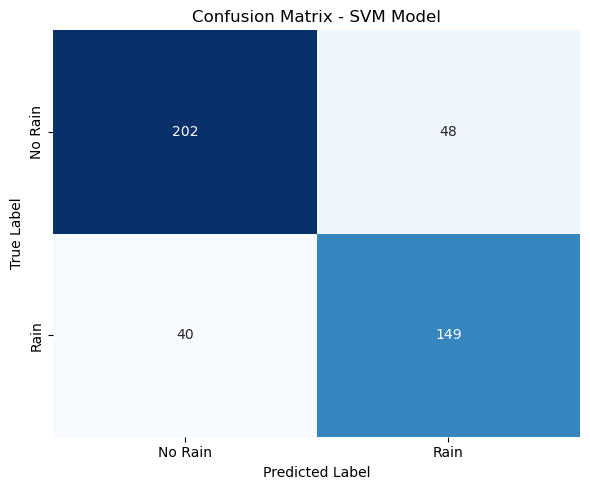

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Model")
plt.tight_layout()
plt.show()


## Curva ROC y capacidad discriminativa

Finalmente, se analiza el desempeño probabilístico del modelo mediante la construcción de la curva ROC (*Receiver Operating Characteristic*).

Esta curva representa la relación entre:

- tasa de verdaderos positivos (*True Positive Rate*)
- tasa de falsos positivos (*False Positive Rate*)

para distintos umbrales de clasificación.

El modelo SVM obtiene un valor de **AUC ≈ 0.88**, indicando una muy buena capacidad para distinguir entre días con lluvia y sin lluvia.

Un valor de AUC cercano a 1 representa un clasificador ideal, mientras que un valor cercano a 0.5 indicaría un comportamiento equivalente al azar. En este caso, el resultado obtenido confirma que el modelo posee una capacidad discriminativa sólida y consistente.

La forma de la curva, claramente por encima de la diagonal aleatoria, refuerza además la calidad del modelo seleccionado y valida el proceso completo de limpieza, ingeniería de variables y ajuste de hiperparámetros realizado a lo largo del proyecto.

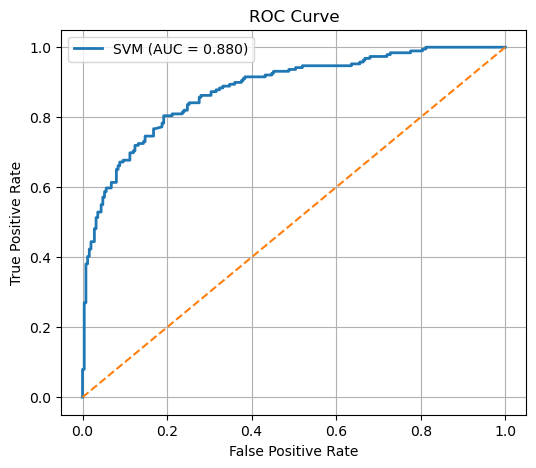

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f"SVM (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
comparison_results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test)

    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df.to_csv(
    "../../data/results/model_comparison.csv",
    index=False
)

In [42]:
params = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **search_log.best_params_
    },
    {
        "Model": "SVM",
        **search_svm.best_params_
    },
    {
        "Model": "XGBoost",
        **search_xgb.best_params_
    }
])

params.to_csv("../../data/results/best_params.csv", index=False)

params

,Model,model__solver,model__penalty,model__C,model__kernel,model__gamma,model__subsample,model__n_estimators,model__max_depth,model__learning_rate,model__colsample_bytree
0,Logistic Regression,sag,l2,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SVM,NaN,NaN,100.0,rbf,0.01,NaN,NaN,NaN,NaN,NaN
2,XGBoost,NaN,NaN,NaN,NaN,NaN,0.7,100.0,3.0,0.1,0.8


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ]
})

final_metrics.to_csv("../../data/results/final_svm_metrics.csv", index=False)

final_metrics

,Metric,Score
0,Accuracy,0.790433
1,Precision,0.756614
2,Recall,0.756614
3,F1,0.756614
4,ROC_AUC,0.879873


In [44]:
predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_Rain": y_proba
})

predictions.to_csv("../../data/results/svm_predictions.csv", index=False)

predictions.head()

,Actual,Predicted,Probability_Rain
0,1,1,0.601234
1,0,1,0.442648
2,0,0,0.033923
3,0,1,0.532240
4,1,1,0.894125


In [45]:
import os
import joblib

os.makedirs("../../models", exist_ok=True)

joblib.dump(
    best_svm,
    "../../models/final_svm_model.pkl"
)

['../../models/final_svm_model.pkl']